In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.12.0+cpu
CUDA Available: False


In [2]:
!pip install -q transformers datasets accelerate evaluate

In [2]:
!pip install transformers datasets scikit-learn

In [3]:
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Imports Successful")

Imports Successful


In [4]:
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(5000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2000))

print(len(train_dataset))
print(len(test_dataset))

5000
2000


In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer Loaded")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\sooda\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:157: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sooda\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\sooda\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded


In [8]:
train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print(train_tokenized)
print(test_tokenized)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 5000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2000
})


In [9]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded


In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_tokenized,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_tokenized,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Created")

DataLoaders Created


In [11]:
import torch
from transformers import AdamW

device = torch.device("cpu")

model.to(device)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer Ready")

C:\Users\sooda\anaconda3\Lib\site-packages\transformers\optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Optimizer Ready


In [12]:
EPOCHS = 1

print("Ready For Training")

Ready For Training


In [13]:
print(type(train_loader))
print(type(test_loader))
print(type(model))
print(type(optimizer))


<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.utils.data.dataloader.DataLoader'>
<class 'transformers.models.distilbert.modeling_distilbert.DistilBertForSequenceClassification'>
<class 'transformers.optimization.AdamW'>


In [14]:
from tqdm import tqdm
import torch

model.train()

running_loss = 0

for batch in tqdm(train_loader):

    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["label"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

avg_train_loss = running_loss / len(train_loader)

print(f"Training Loss: {avg_train_loss:.4f}")

100%|██████████████████████████████████████████████████████████████████████████████| 625/625 [2:42:30<00:00, 15.60s/it]

Training Loss: 0.3646


In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

print("\nRESULTS")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("="*50)

100%|████████████████████████████████████████████████████████████████████████████████| 250/250 [11:45<00:00,  2.82s/it]



RESULTS
Accuracy  : 0.8705
Precision : 0.8299
Recall    : 0.9320
F1 Score  : 0.8780


In [16]:
import os

MODEL_DIR = "saved_models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

torch.save(
    model.state_dict(),
    os.path.join(
        MODEL_DIR,
        "distilbert_sentiment.pth"
    )
)

print("Model Saved Successfully")

Model Saved Successfully


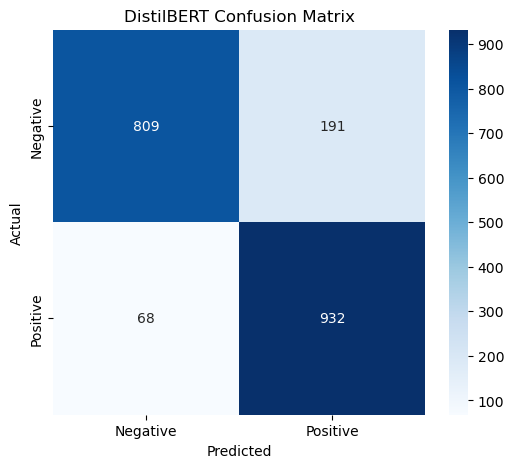

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

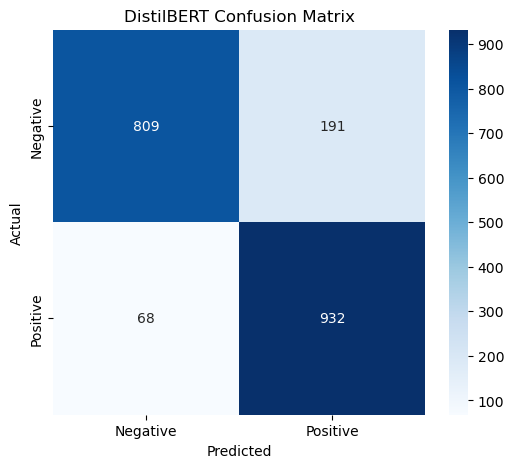

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "distilbert_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=["Negative", "Positive"]
)

print(report)

              precision    recall  f1-score   support

    Negative       0.92      0.81      0.86      1000
    Positive       0.83      0.93      0.88      1000

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



In [20]:
with open(
    "distilbert_classification_report.txt",
    "w"
) as f:
    f.write(report)

print("Classification Report Saved")

Classification Report Saved


In [21]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Custom LSTM",
        "AWD-LSTM",
        "DistilBERT"
    ],
    "Accuracy": [
        0.8512,
        0.8948,
        0.8700
    ],
    "Precision": [
        0.8641,
        0.8819,
        0.8800
    ],
    "Recall": [
        0.8335,
        0.9057,
        0.8700
    ],
    "F1 Score": [
        0.8485,
        0.8937,
        0.8700
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom LSTM,0.8512,0.8641,0.8335,0.8485
1,AWD-LSTM,0.8948,0.8819,0.9057,0.8937
2,DistilBERT,0.8700,0.8800,0.8700,0.8700


In [22]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)